# 📊 BigMart Sales Prediction — EDA
**Notebook 01 | Exploratory Data Analysis**

Steps covered:
1. Load & Inspect Data
2. Missing Value Analysis
3. Univariate Analysis
4. Bivariate Analysis
5. Correlation Heatmap
6. Key Insights Summary

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
PALETTE = 'Set2'
print('Libraries loaded ✅')

Libraries loaded ✅


## 1️⃣  Load & Inspect Data

In [2]:
df = pd.read_csv('../data/Train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Basic Statistics ===')
df.describe(include='all').T

=== Data Types ===
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

=== Basic Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDW13,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Cardinality of categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col:40s} | unique: {df[col].nunique():4d} | values: {df[col].unique()[:5]}')

Item_Identifier                          | unique: 1559 | values: ['FDA15' 'DRC01' 'FDN15' 'FDX07' 'NCD19']
Item_Fat_Content                         | unique:    5 | values: ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
Item_Type                                | unique:   16 | values: ['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household']
Outlet_Identifier                        | unique:   10 | values: ['OUT049' 'OUT018' 'OUT010' 'OUT013' 'OUT027']
Outlet_Size                              | unique:    3 | values: ['Medium' nan 'High' 'Small']
Outlet_Location_Type                     | unique:    3 | values: ['Tier 1' 'Tier 3' 'Tier 2']
Outlet_Type                              | unique:    4 | values: ['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


## 2️⃣  Missing Value Analysis

             Missing  Pct (%)
Outlet_Size     2410    28.28
Item_Weight     1463    17.17


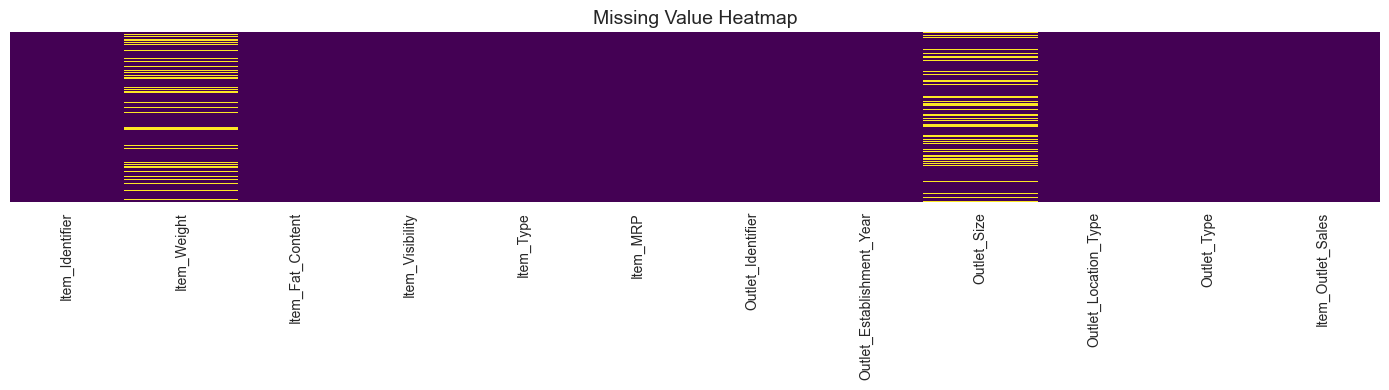

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct (%)', ascending=False)
print(missing_df)

# Heatmap of nulls
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 3️⃣  Univariate Analysis

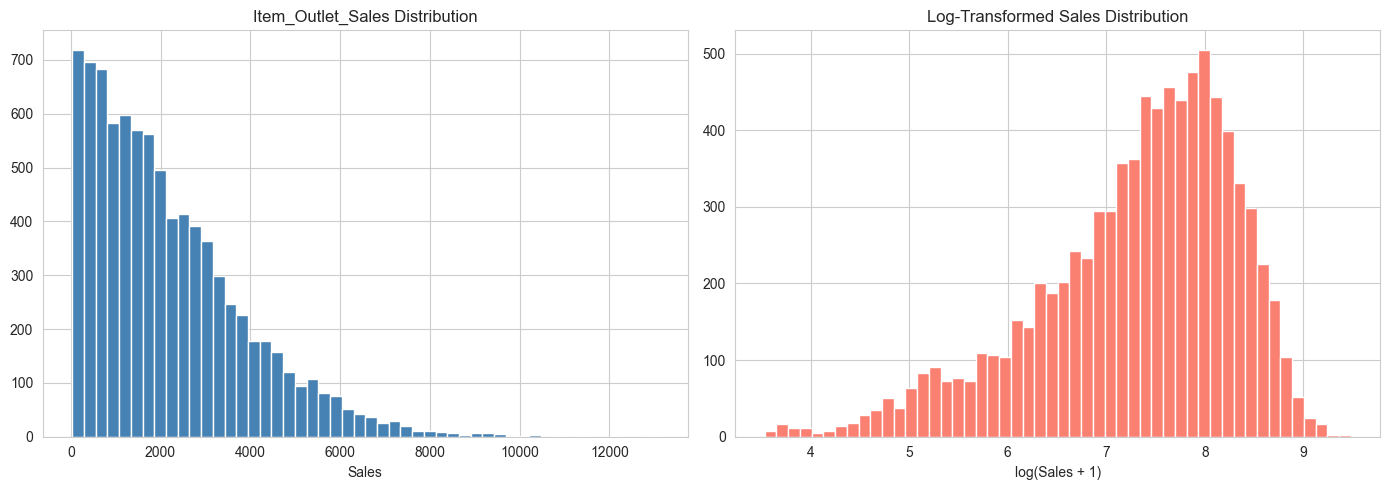

In [6]:
# ── Target variable distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Item_Outlet_Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Item_Outlet_Sales Distribution')
axes[0].set_xlabel('Sales')

axes[1].hist(np.log1p(df['Item_Outlet_Sales']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Log-Transformed Sales Distribution')
axes[1].set_xlabel('log(Sales + 1)')

plt.tight_layout()
plt.show()

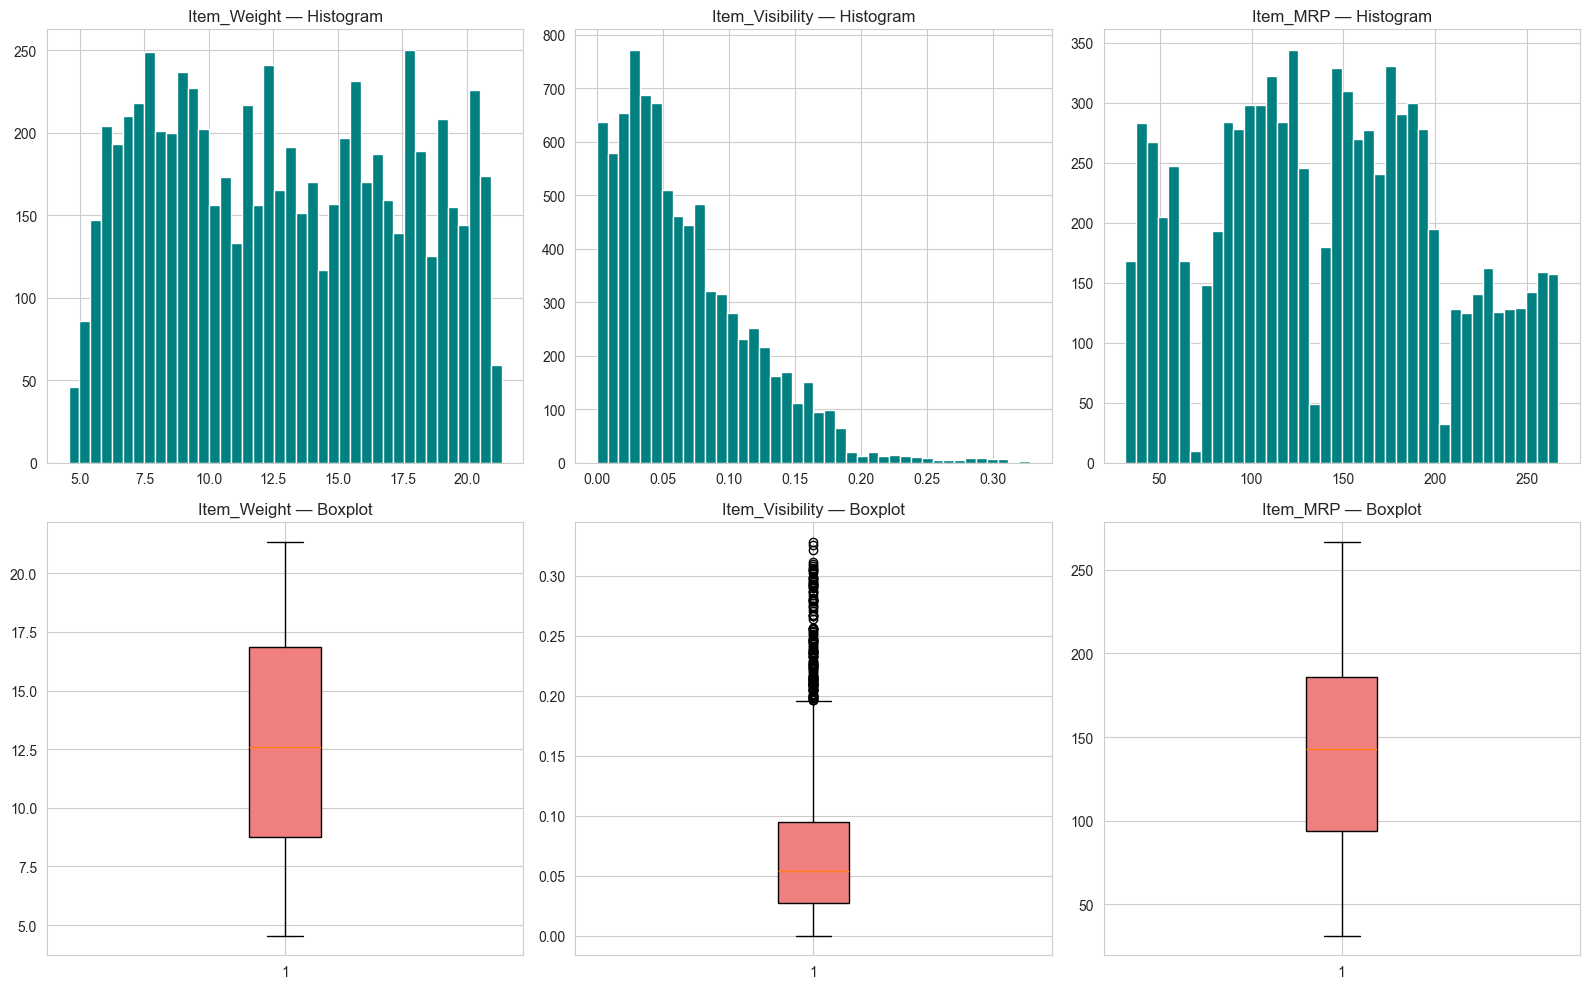

In [7]:
# ── Numerical features ─────────────────────────────────────────────────────
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(num_cols):
    df[col].dropna().hist(ax=axes[0, i], bins=40, color='teal', edgecolor='white')
    axes[0, i].set_title(f'{col} — Histogram')

    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightcoral'))
    axes[1, i].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.show()

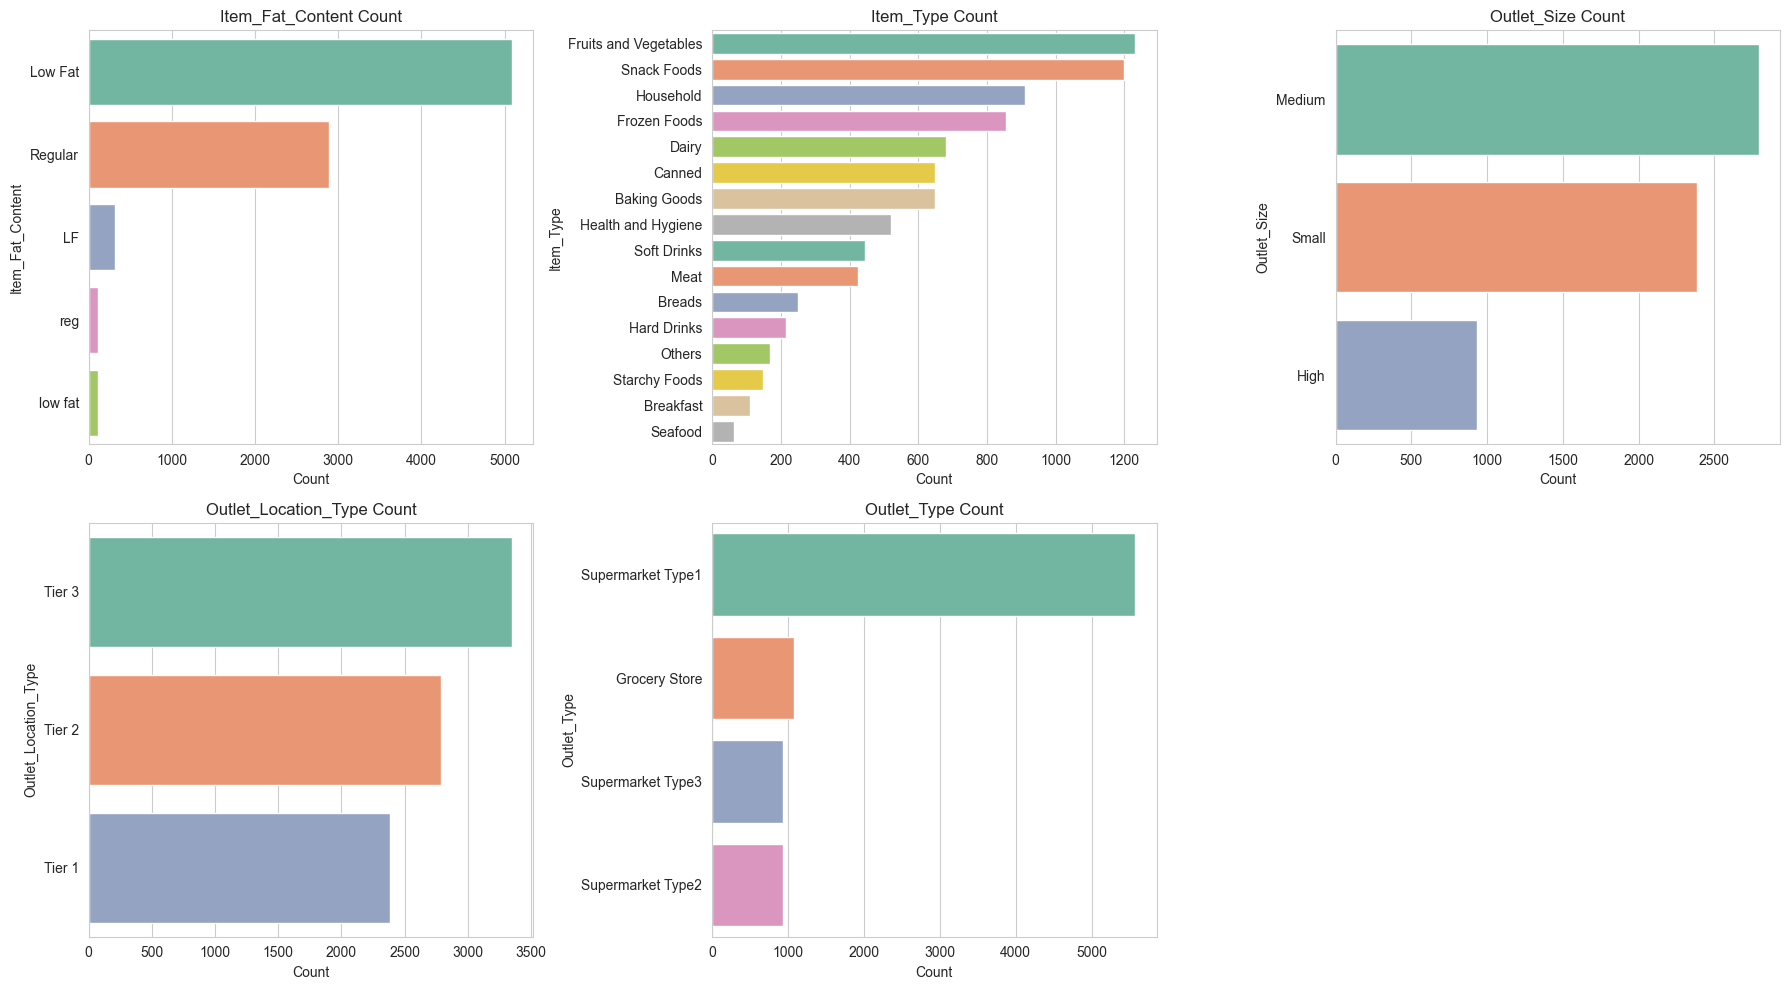

In [8]:
# ── Categorical features ───────────────────────────────────────────────────
cat_cols_plot = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
                 'Outlet_Location_Type', 'Outlet_Type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, palette=PALETTE, ax=axes[i])
    axes[i].set_title(f'{col} Count')
    axes[i].set_xlabel('Count')

axes[-1].axis('off')   # hide empty subplot
plt.tight_layout()
plt.show()

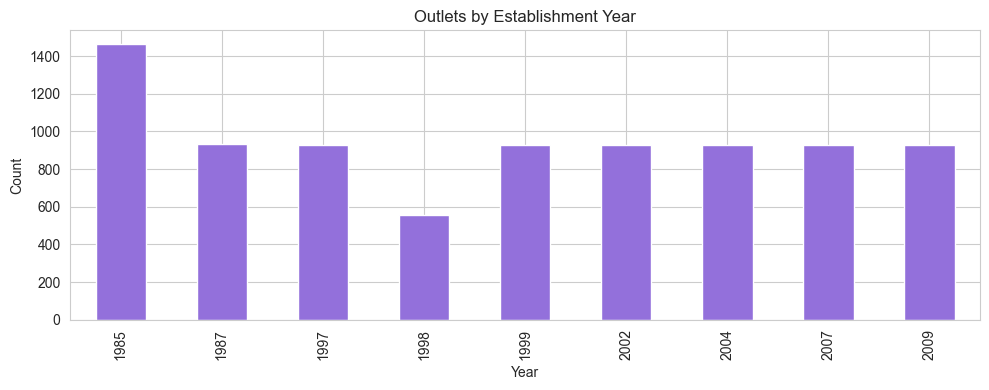

In [9]:
# Outlet Establishment Year
plt.figure(figsize=(10, 4))
df['Outlet_Establishment_Year'].value_counts().sort_index().plot(kind='bar', color='mediumpurple')
plt.title('Outlets by Establishment Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4️⃣  Bivariate Analysis — Features vs Sales

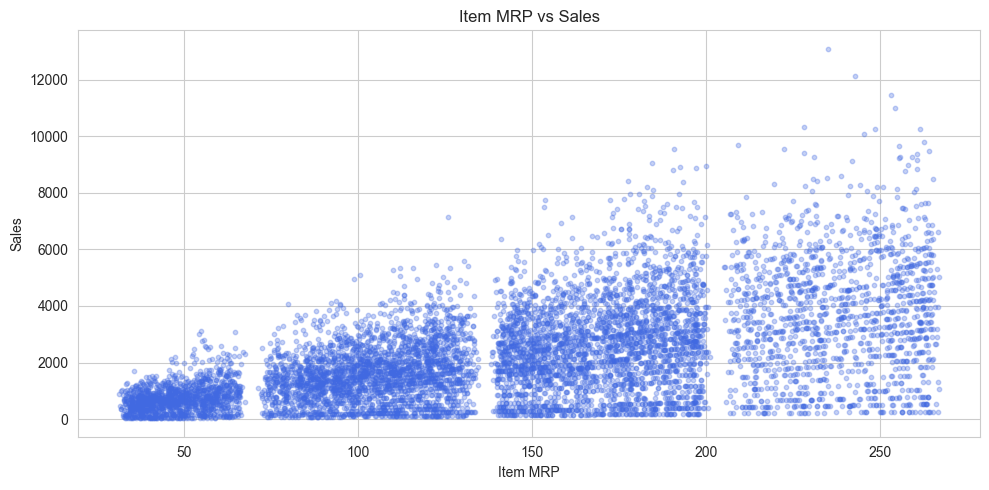

In [10]:
# MRP vs Sales (strongest expected predictor)
plt.figure(figsize=(10, 5))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.3, color='royalblue', s=10)
plt.title('Item MRP vs Sales')
plt.xlabel('Item MRP')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

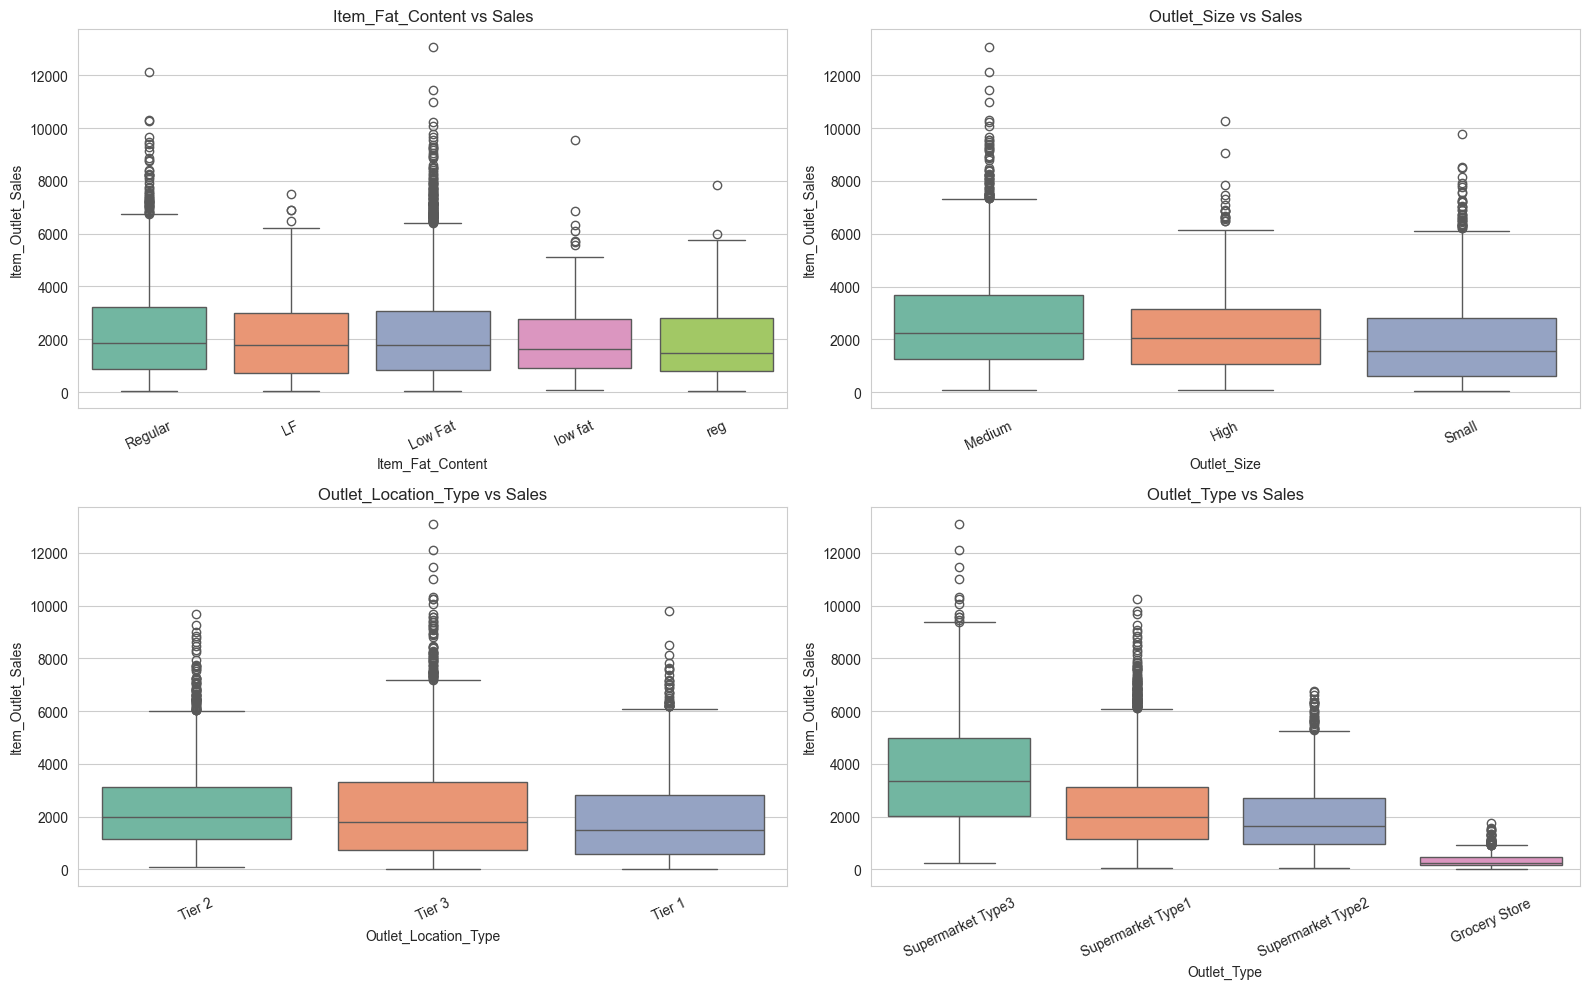

In [11]:
# Categorical vs Sales boxplots
cat_vs_sales = ['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vs_sales):
    order = df.groupby(col)['Item_Outlet_Sales'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Item_Outlet_Sales', order=order,
                palette=PALETTE, ax=axes[i])
    axes[i].set_title(f'{col} vs Sales')
    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

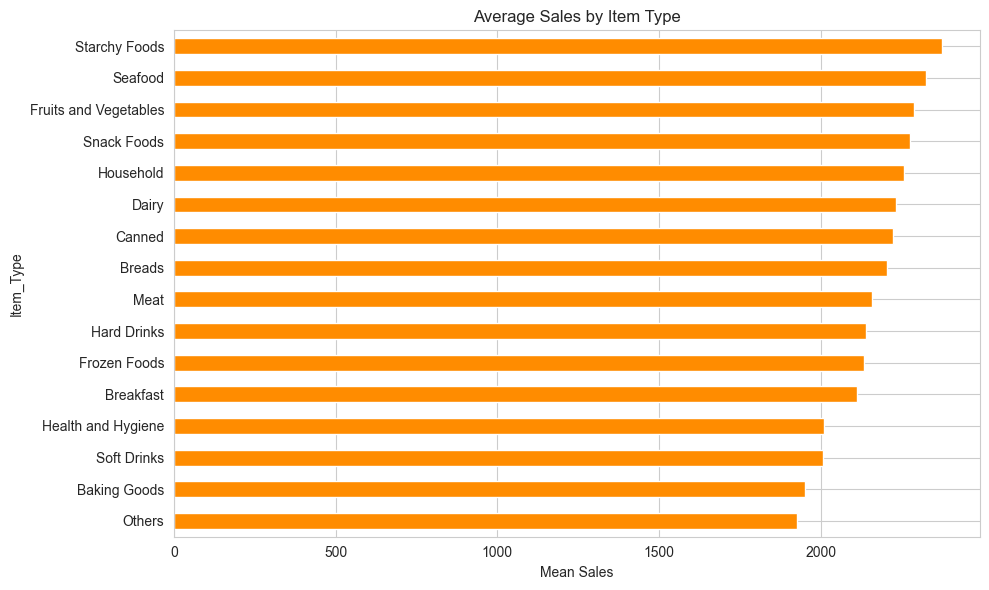

In [12]:
# Item Type vs Average Sales
avg_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
avg_sales.plot(kind='barh', color='darkorange')
plt.title('Average Sales by Item Type')
plt.xlabel('Mean Sales')
plt.tight_layout()
plt.show()

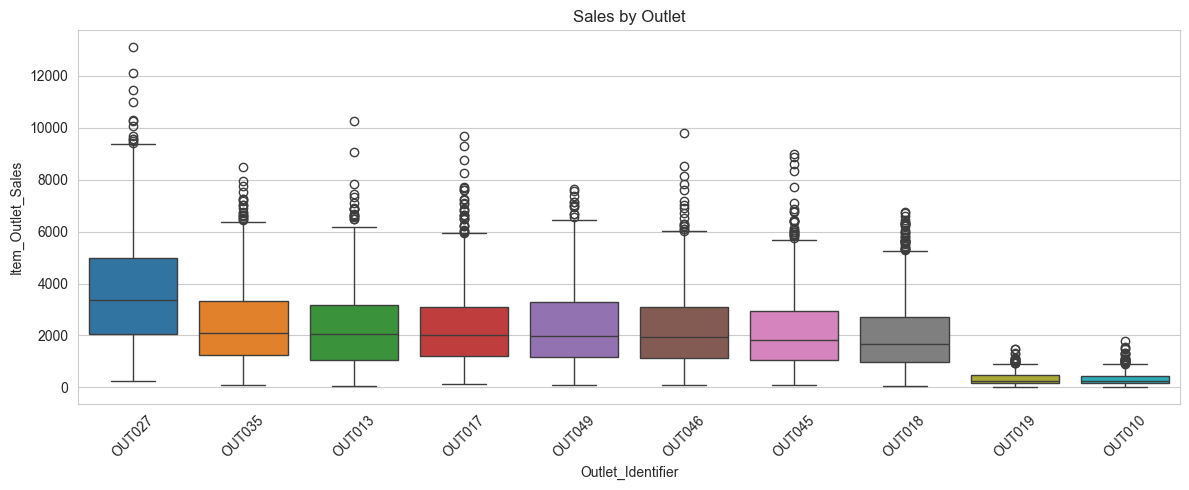

In [13]:
# Outlet Identifier vs Sales
plt.figure(figsize=(12, 5))
order = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Identifier', y='Item_Outlet_Sales', order=order, palette='tab10')
plt.title('Sales by Outlet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5️⃣  Correlation Heatmap

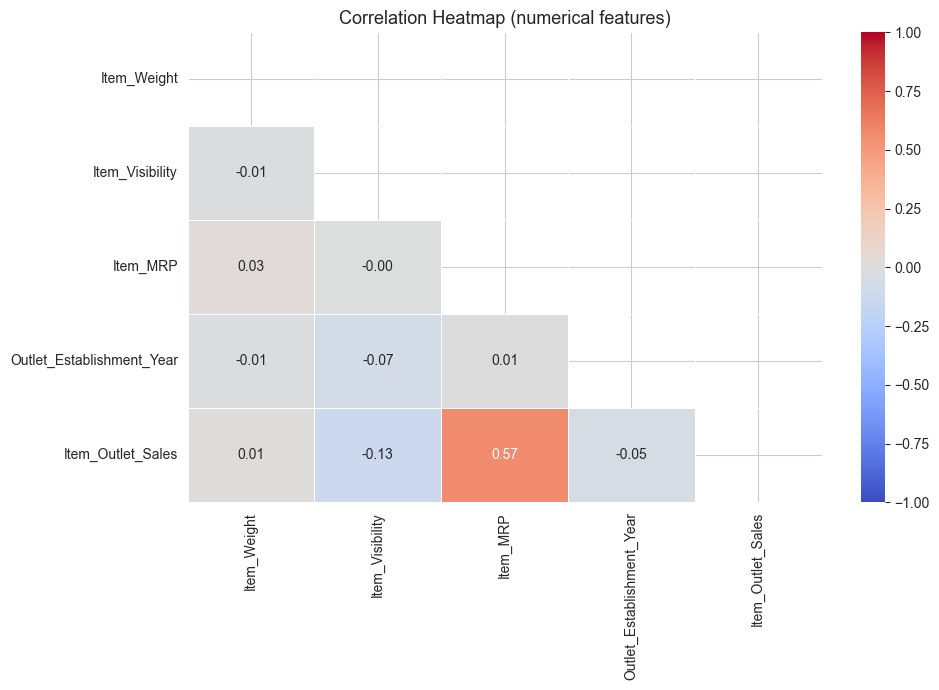

In [14]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (numerical features)', fontsize=13)
plt.tight_layout()
plt.show()

## 6️⃣  Key Insights Summary

In [15]:
insights = [
    '1. Item_MRP is the strongest predictor of sales (clear positive correlation).',
    '2. Item_Weight has ~17% missing values — impute with item-category median.',
    '3. Outlet_Size has ~28% missing values — impute using Outlet_Type mode.',
    '4. Item_Fat_Content has inconsistent labels (LF, low fat, Low Fat) — needs cleaning.',
    '5. Item_Visibility has many zeroes — likely data entry error; replace with category mean.',
    '6. Outlet_Type "Grocery Store" has significantly lower sales than Supermarket types.',
    '7. Sales are right-skewed — log transform will help tree-based and linear models.',
    '8. Older outlets (est. 1985) tend to have higher sales — Outlet_Age is a useful feature.',
]
for i in insights:
    print(i)

1. Item_MRP is the strongest predictor of sales (clear positive correlation).
2. Item_Weight has ~17% missing values — impute with item-category median.
3. Outlet_Size has ~28% missing values — impute using Outlet_Type mode.
4. Item_Fat_Content has inconsistent labels (LF, low fat, Low Fat) — needs cleaning.
5. Item_Visibility has many zeroes — likely data entry error; replace with category mean.
6. Outlet_Type "Grocery Store" has significantly lower sales than Supermarket types.
7. Sales are right-skewed — log transform will help tree-based and linear models.
8. Older outlets (est. 1985) tend to have higher sales — Outlet_Age is a useful feature.
